In [ ]:
# Notebook 06 - Improved Tier-1 Baselines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed. Run: pip install xgboost")

from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/bahaa1515/EECE-693-project.git"
COLAB_REPO_DIR = Path("/content/EECE-693-project")

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate
    if COLAB_REPO_DIR.exists() and (COLAB_REPO_DIR / "src" / "config.py").exists():
        return COLAB_REPO_DIR
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError as exc:
        raise FileNotFoundError(
            "Could not find the project root. Run this notebook from the repo root, "
            "from the notebooks folder, or clone the repo in Colab first."
        ) from exc
    subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    return COLAB_REPO_DIR

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

from src.config import DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES

print("Imports OK | XGBoost available:", HAS_XGB)


In [2]:
# ── Load labeled data (must be regenerated from NB04 with fixed thresholds) ──
labeled_path = DATA_PROCESSED / "baseline_smartwatch_features_labeled.parquet"
df = pd.read_parquet(labeled_path)

print("Shape:", df.shape)
print("Users:", df["user_key"].nunique())
print()
print("Target distribution:")
print(df["target_binary"].value_counts(dropna=False))
print()
print(f"Positive rate: {df['target_binary'].mean()*100:.1f}%")
print(f"Negative rate: {(1 - df['target_binary'].mean())*100:.1f}%")

Shape: (31125, 47)
Users: 18

Target distribution:
target_binary
0.0    25753
1.0     5372
Name: count, dtype: int64

Positive rate: 17.3%
Negative rate: 82.7%


In [3]:
# ── Feature columns (same 32 as NB05) ──────────────────────────────────────
feature_cols = [
    "observed_minutes", "coverage", "n_rows_in_window",
    "hr_mean", "hr_std", "hr_min", "hr_max", "hr_median", "hr_missing_pct",
    "steps_sum", "steps_mean", "steps_max",
    "intensity_mean", "intensity_std", "intensity_max",
    "active_minute_frac",
    "activity_frac_walk", "activity_frac_running", "activity_frac_activity_high",
    "activity_frac_sedentary", "activity_frac_sleep", "activity_frac_not_worn",
    "activity_frac_charging", "activity_frac_unknown",
    "day_hr_mean", "night_hr_mean",
    "day_steps_sum", "night_steps_sum",
    "day_active_frac", "night_active_frac",
    "hr_slope", "steps_slope",
]

X = df[feature_cols].copy()
y = df["target_binary"].astype(int).copy()
groups = df["user_key"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}  |  Positive: {y.sum()}  |  Negative: {(y==0).sum()}")
print(f"Unique users: {groups.nunique()}")

X shape: (31125, 32)
y shape: (31125,)  |  Positive: 5372  |  Negative: 25753
Unique users: 18


In [4]:
# ── Train / Test split (user-stratified, same as NB05) ──────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]
groups_test  = groups.iloc[test_idx]

print(f"Train: {X_train.shape[0]} samples, {groups_train.nunique()} users")
print(f"Test:  {X_test.shape[0]} samples, {groups_test.nunique()} users")
print(f"User overlap: {set(groups_train.unique()) & set(groups_test.unique())}")
print()
print("Train target:", dict(y_train.value_counts()), f"({y_train.mean()*100:.1f}% pos)")
print("Test target: ", dict(y_test.value_counts()), f"({y_test.mean()*100:.1f}% pos)")

Train: 17586 samples, 13 users
Test:  13539 samples, 5 users
User overlap: set()

Train target: {0: np.int64(16278), 1: np.int64(1308)} (7.4% pos)
Test target:  {0: np.int64(9475), 1: np.int64(4064)} (30.0% pos)


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 4 — Majority-class (trivial) baseline
# ══════════════════════════════════════════════════════════════════════════
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)

print("=" * 60)
print("TRIVIAL BASELINE: predict all =", majority_class)
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, baseline_pred):.4f}")
print(f"  Precision: {precision_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, baseline_pred, zero_division=0):.4f}")
print(f"  F1:        {f1_score(y_test, baseline_pred, zero_division=0):.4f}")
print()
print("Every real model MUST beat these numbers to be considered useful.")

TRIVIAL BASELINE: predict all = 0
  Accuracy:  0.6998
  Precision: 0.0000
  Recall:    0.0000
  F1:        0.0000

Every real model MUST beat these numbers to be considered useful.


In [6]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5 + 6 + 7 — Train LR, RF, XGBoost with full diagnostics
# ══════════════════════════════════════════════════════════════════════════

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train, predict, and return results + diagnostics."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_score is not None:
        results["roc_auc"] = roc_auc_score(y_test, y_score)
        results["pr_auc"] = average_precision_score(y_test, y_score)
        results["brier"] = brier_score_loss(y_test, y_score)
    else:
        results["roc_auc"] = results["pr_auc"] = results["brier"] = np.nan

    # Print results
    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted 0   Predicted 1")
    print(f"  Actual 0:      {tn:>8d}       {fp:>8d}")
    print(f"  Actual 1:      {fn:>8d}       {tp:>8d}")
    print()
    print(classification_report(y_test, y_pred, zero_division=0,
                                target_names=["No exacerb.", "Exacerbation"]))
    if y_score is not None:
        print(f"  ROC-AUC:  {results['roc_auc']:.4f}")
        print(f"  PR-AUC:   {results['pr_auc']:.4f}")
        print(f"  Brier:    {results['brier']:.4f}")

    return results, y_pred, y_score, cm

print("evaluate_model() defined.")

evaluate_model() defined.


In [7]:
# ── Logistic Regression ──────────────────────────────────────────────────────
logreg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_results, logreg_pred, logreg_score, logreg_cm = evaluate_model(
    "Logistic Regression", logreg_model, X_train, y_train, X_test, y_test
)


MODEL: Logistic Regression

Confusion Matrix:
                 Predicted 0   Predicted 1
  Actual 0:          6210           3265
  Actual 1:          2089           1975

              precision    recall  f1-score   support

 No exacerb.       0.75      0.66      0.70      9475
Exacerbation       0.38      0.49      0.42      4064

    accuracy                           0.60     13539
   macro avg       0.56      0.57      0.56     13539
weighted avg       0.64      0.60      0.62     13539

  ROC-AUC:  0.4976
  PR-AUC:   0.3367
  Brier:    0.2839


In [ ]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ))
])

rf_results, rf_pred, rf_score, rf_cm = evaluate_model(
    "Random Forest", rf_model, X_train, y_train, X_test, y_test
)


In [ ]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
if HAS_XGB:
    # Compute scale_pos_weight for class imbalance
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    spw = neg_count / pos_count if pos_count > 0 else 1.0
    print(f"scale_pos_weight = {spw:.2f}  (neg/pos = {neg_count}/{pos_count})")

    xgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=spw,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1
        ))
    ])

    xgb_results, xgb_pred, xgb_score, xgb_cm = evaluate_model(
        "XGBoost", xgb_model, X_train, y_train, X_test, y_test
    )
else:
    print("Skipping XGBoost (not installed).")
    xgb_results = xgb_pred = xgb_score = xgb_cm = None


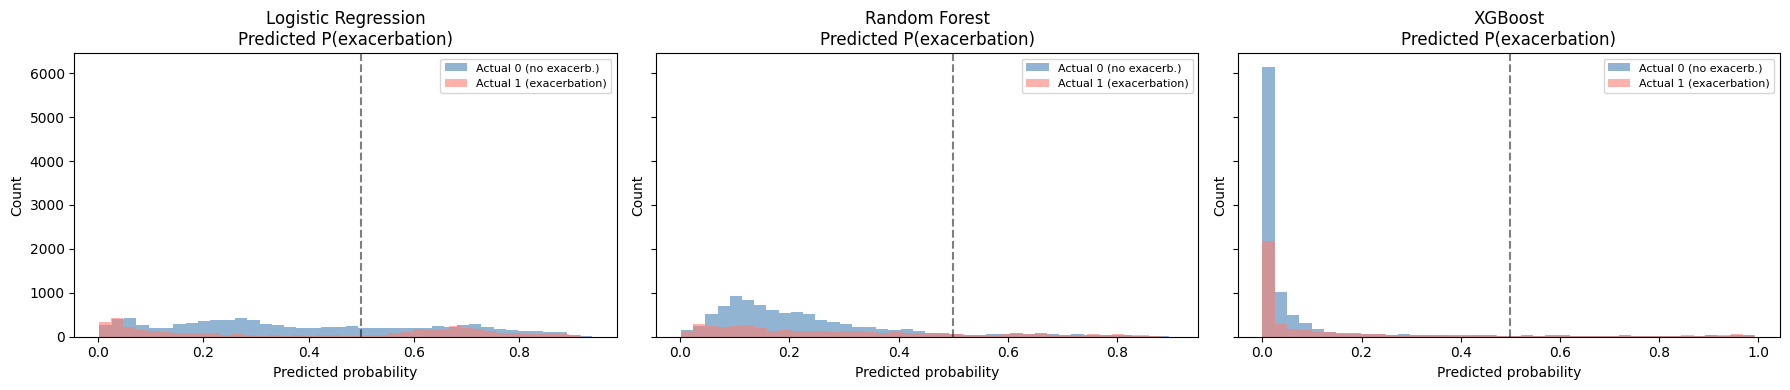

If both classes overlap heavily near 0.5, the model is not separating well.
Good separation = class 0 peaks near 0.0, class 1 peaks near 1.0.


In [10]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 6 — Probability histograms (per model)
# ══════════════════════════════════════════════════════════════════════════
models_info = [
    ("Logistic Regression", logreg_score),
    ("Random Forest", rf_score),
]
if HAS_XGB and xgb_score is not None:
    models_info.append(("XGBoost", xgb_score))

n_models = len(models_info)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (name, scores) in zip(axes, models_info):
    if scores is None:
        continue
    mask_0 = (y_test == 0).values
    mask_1 = (y_test == 1).values
    ax.hist(scores[mask_0], bins=40, alpha=0.6, label="Actual 0 (no exacerb.)", color="steelblue")
    ax.hist(scores[mask_1], bins=40, alpha=0.6, label="Actual 1 (exacerbation)", color="salmon")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Count")
    ax.set_title(f"{name}\nPredicted P(exacerbation)")
    ax.legend(fontsize=8)
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "probability_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("If both classes overlap heavily near 0.5, the model is not separating well.")
print("Good separation = class 0 peaks near 0.0, class 1 peaks near 1.0.")

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 8 — Grouped k-fold cross-validation
# ══════════════════════════════════════════════════════════════════════════
from sklearn.base import clone

def grouped_cv(model_template, X, y, groups, n_splits=5):
    """Run GroupKFold CV and return per-fold metrics."""
    gkf = GroupKFold(n_splits=n_splits)
    fold_results = []

    for fold_i, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
        mdl = clone(model_template)
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        mdl.fit(X_tr, y_tr)
        y_p = mdl.predict(X_te)
        y_s = mdl.predict_proba(X_te)[:, 1] if hasattr(mdl, "predict_proba") else None

        row = {
            "fold": fold_i,
            "n_test": len(y_te),
            "test_users": groups.iloc[te_idx].nunique(),
            "pos_rate": y_te.mean(),
            "accuracy": accuracy_score(y_te, y_p),
            "precision": precision_score(y_te, y_p, zero_division=0),
            "recall": recall_score(y_te, y_p, zero_division=0),
            "f1": f1_score(y_te, y_p, zero_division=0),
        }
        if y_s is not None:
            try:
                row["roc_auc"] = roc_auc_score(y_te, y_s)
            except ValueError:
                row["roc_auc"] = np.nan
            row["pr_auc"] = average_precision_score(y_te, y_s)
            row["brier"] = brier_score_loss(y_te, y_s)
        fold_results.append(row)

    return pd.DataFrame(fold_results)

print("Running 5-fold GroupKFold CV for each model...")
print("(This may take a minute)")

Running 5-fold GroupKFold CV for each model...
(This may take a minute)


In [12]:
# ── CV: Logistic Regression ──
cv_logreg = grouped_cv(logreg_model, X, y, groups, n_splits=5)
print("Logistic Regression — Per-fold results:")
print(cv_logreg.to_string(index=False))
print(f"\n  Mean F1: {cv_logreg['f1'].mean():.4f} +/- {cv_logreg['f1'].std():.4f}")
if 'roc_auc' in cv_logreg:
    print(f"  Mean ROC-AUC: {cv_logreg['roc_auc'].mean():.4f} +/- {cv_logreg['roc_auc'].std():.4f}")

Logistic Regression — Per-fold results:
 fold  n_test  test_users  pos_rate  accuracy  precision   recall       f1  roc_auc   pr_auc    brier
    0    6151           4  0.369859  0.530971   0.164835 0.065934 0.094192 0.392725 0.294860 0.361801
    1    6187           4  0.279295  0.664781   0.421931 0.541088 0.474138 0.705250 0.391165 0.202038
    2    6166           4  0.118391  0.737755   0.194349 0.386301 0.258597 0.648315 0.204554 0.180235
    3    6235           3  0.053889  0.828228   0.143550 0.440476 0.216533 0.743814 0.135274 0.144699
    4    6386           3  0.047448  0.925149   0.000000 0.000000 0.000000 0.390025 0.035927 0.072305

  Mean F1: 0.2087 +/- 0.1801
  Mean ROC-AUC: 0.5760 +/- 0.1720


In [13]:
# ── CV: Random Forest ──
cv_rf = grouped_cv(rf_model, X, y, groups, n_splits=5)
print("Random Forest — Per-fold results:")
print(cv_rf.to_string(index=False))
print(f"\n  Mean F1: {cv_rf['f1'].mean():.4f} +/- {cv_rf['f1'].std():.4f}")
if 'roc_auc' in cv_rf:
    print(f"  Mean ROC-AUC: {cv_rf['roc_auc'].mean():.4f} +/- {cv_rf['roc_auc'].std():.4f}")

Random Forest — Per-fold results:
 fold  n_test  test_users  pos_rate  accuracy  precision   recall       f1  roc_auc   pr_auc    brier
    0    6151           4  0.369859  0.583970   0.160287 0.029451 0.049759 0.421334 0.305806 0.338793
    1    6187           4  0.279295  0.672862   0.437972 0.604745 0.508021 0.744251 0.453619 0.190867
    2    6166           4  0.118391  0.876095   0.381944 0.075342 0.125858 0.721841 0.244068 0.107128
    3    6235           3  0.053889  0.932478   0.000000 0.000000 0.000000 0.692288 0.110488 0.079567
    4    6386           3  0.047448  0.947228   0.000000 0.000000 0.000000 0.279071 0.031623 0.065164

  Mean F1: 0.1367 +/- 0.2139
  Mean ROC-AUC: 0.5718 +/- 0.2092


In [14]:
# ── CV: XGBoost ──
if HAS_XGB and xgb_model is not None:
    cv_xgb = grouped_cv(xgb_model, X, y, groups, n_splits=5)
    print("XGBoost — Per-fold results:")
    print(cv_xgb.to_string(index=False))
    print(f"\n  Mean F1: {cv_xgb['f1'].mean():.4f} +/- {cv_xgb['f1'].std():.4f}")
    if 'roc_auc' in cv_xgb:
        print(f"  Mean ROC-AUC: {cv_xgb['roc_auc'].mean():.4f} +/- {cv_xgb['roc_auc'].std():.4f}")
else:
    cv_xgb = None
    print("XGBoost skipped.")

XGBoost — Per-fold results:
 fold  n_test  test_users  pos_rate  accuracy  precision   recall       f1  roc_auc   pr_auc    brier
    0    6151           4  0.369859  0.610470   0.255061 0.027692 0.049960 0.374964 0.300278 0.370715
    1    6187           4  0.279295  0.705673   0.470846 0.434606 0.452001 0.747620 0.466580 0.197042
    2    6166           4  0.118391  0.864742   0.237374 0.064384 0.101293 0.636504 0.172420 0.114998
    3    6235           3  0.053889  0.897514   0.154897 0.202381 0.175484 0.716975 0.124719 0.078212
    4    6386           3  0.047448  0.941904   0.000000 0.000000 0.000000 0.235346 0.028836 0.056354

  Mean F1: 0.1557 +/- 0.1779
  Mean ROC-AUC: 0.5423 +/- 0.2257


In [15]:
# ── CV Summary Table ──────────────────────────────────────────────────────
cv_summary_rows = []
for name, cv_df in [("Logistic Regression", cv_logreg), ("Random Forest", cv_rf)]:
    row = {"model": name}
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier"]:
        if metric in cv_df:
            row[f"{metric}_mean"] = cv_df[metric].mean()
            row[f"{metric}_std"] = cv_df[metric].std()
    cv_summary_rows.append(row)

if cv_xgb is not None:
    row = {"model": "XGBoost"}
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier"]:
        if metric in cv_xgb:
            row[f"{metric}_mean"] = cv_xgb[metric].mean()
            row[f"{metric}_std"] = cv_xgb[metric].std()
    cv_summary_rows.append(row)

cv_summary = pd.DataFrame(cv_summary_rows)
print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY (5-fold GroupKFold)")
print("="*60)
for _, r in cv_summary.iterrows():
    print(f"\n  {r['model']}:")
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier"]:
        mean_key, std_key = f"{metric}_mean", f"{metric}_std"
        if mean_key in r and not pd.isna(r[mean_key]):
            print(f"    {metric:12s}: {r[mean_key]:.4f} +/- {r[std_key]:.4f}")


CROSS-VALIDATION SUMMARY (5-fold GroupKFold)

  Logistic Regression:
    accuracy    : 0.7374 +/- 0.1512
    precision   : 0.1849 +/- 0.1521
    recall      : 0.2868 +/- 0.2394
    f1          : 0.2087 +/- 0.1801
    roc_auc     : 0.5760 +/- 0.1720
    pr_auc      : 0.2124 +/- 0.1378
    brier       : 0.1922 +/- 0.1068

  Random Forest:
    accuracy    : 0.8025 +/- 0.1642
    precision   : 0.1960 +/- 0.2069
    recall      : 0.1419 +/- 0.2606
    f1          : 0.1367 +/- 0.2139
    roc_auc     : 0.5718 +/- 0.2092
    pr_auc      : 0.2291 +/- 0.1655
    brier       : 0.1563 +/- 0.1130

  XGBoost:
    accuracy    : 0.8041 +/- 0.1402
    precision   : 0.2236 +/- 0.1710
    recall      : 0.1458 +/- 0.1792
    f1          : 0.1557 +/- 0.1779
    roc_auc     : 0.5423 +/- 0.2257
    pr_auc      : 0.2186 +/- 0.1696
    brier       : 0.1635 +/- 0.1276


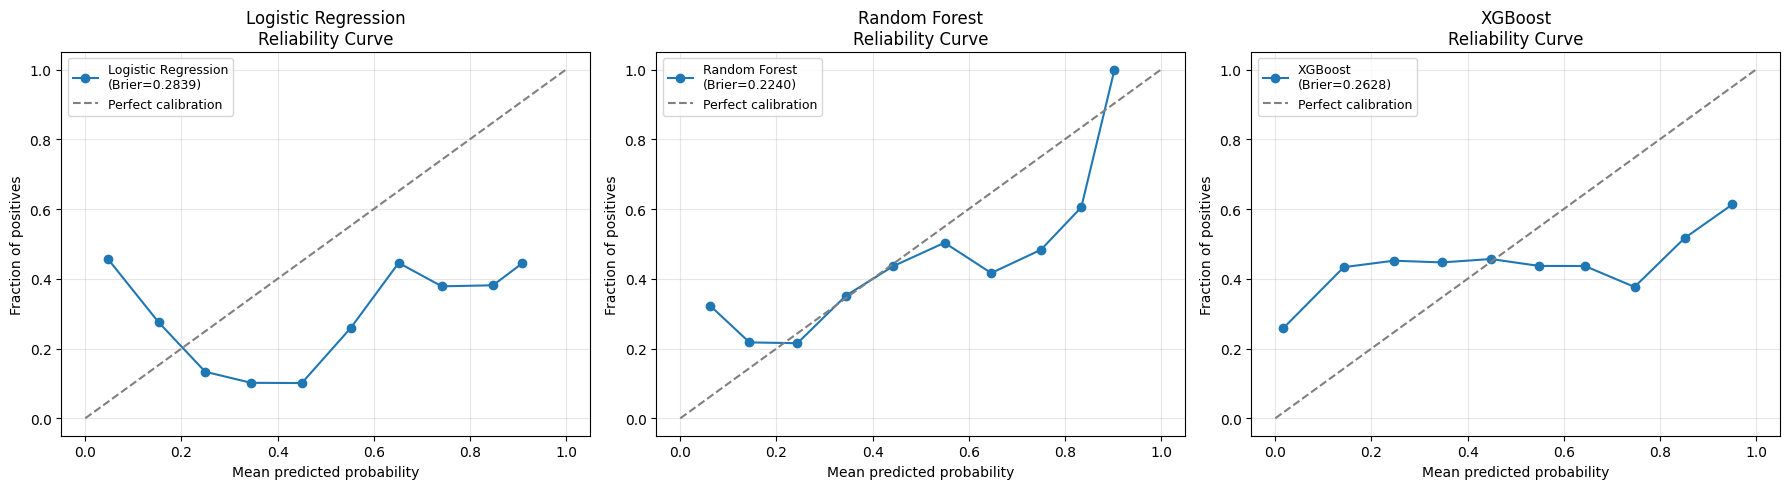

Points on the diagonal = well-calibrated.
Above diagonal = under-confident. Below = over-confident.


In [16]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 9 — Calibration evaluation (Brier score + reliability curves)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, scores) in zip(axes, models_info):
    if scores is None:
        continue
    prob_true, prob_pred = calibration_curve(y_test, scores, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_test, scores)

    ax.plot(prob_pred, prob_true, marker='o', label=f'{name}\n(Brier={brier:.4f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{name}\nReliability Curve')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Points on the diagonal = well-calibrated.")
print("Above diagonal = under-confident. Below = over-confident.")

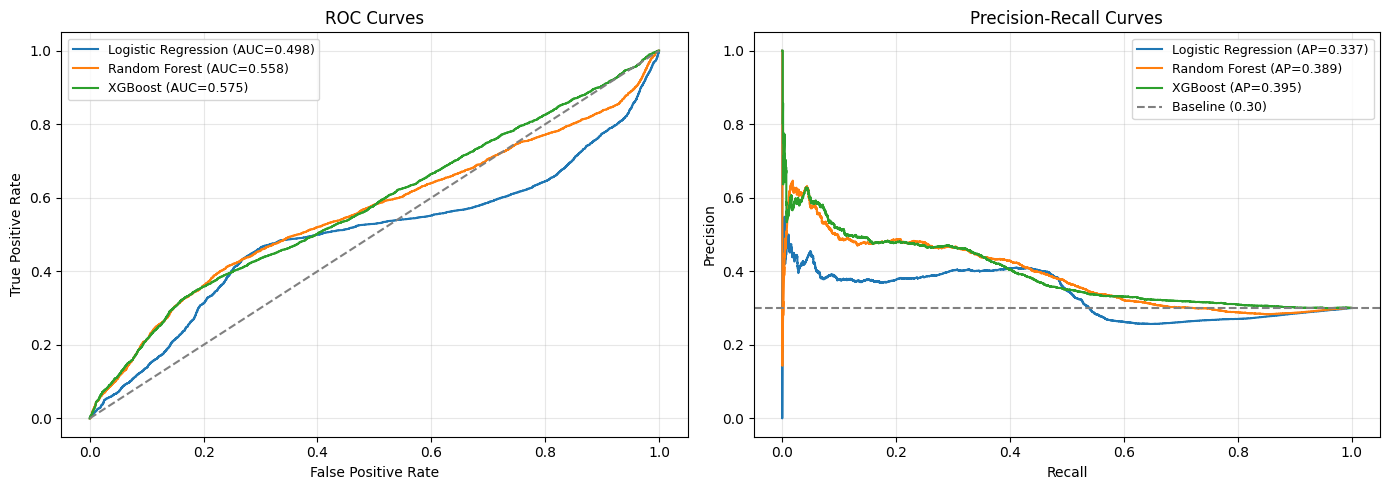

In [17]:
# ══════════════════════════════════════════════════════════════════════════
# ROC & PR Curves — All models on one plot
# ══════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, scores in models_info:
    if scores is None:
        continue
    # ROC
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val = roc_auc_score(y_test, scores)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

    # PR
    prec, rec, _ = precision_recall_curve(y_test, scores)
    ap_val = average_precision_score(y_test, scores)
    ax2.plot(rec, prec, label=f"{name} (AP={ap_val:.3f})")

ax1.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

baseline_pr = y_test.mean()
ax2.axhline(baseline_pr, linestyle='--', color='gray', label=f'Baseline ({baseline_pr:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "roc_pr_curves_tier1.png", dpi=150, bbox_inches="tight")
plt.show()

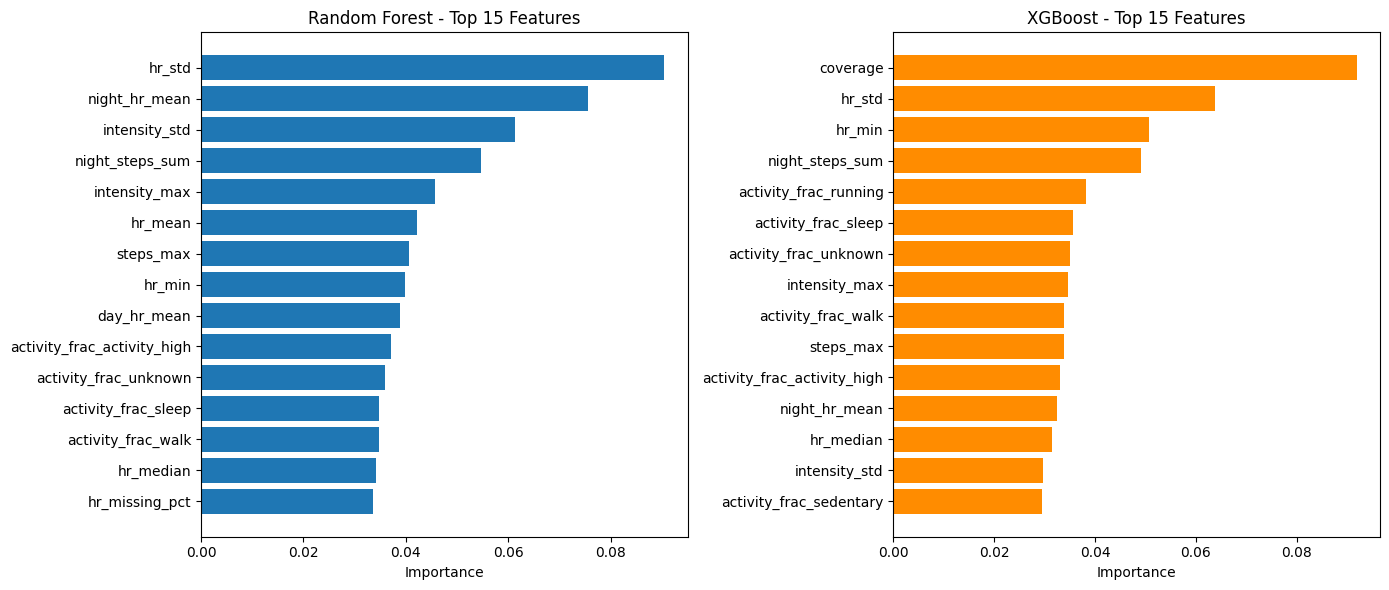

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# Feature importances — XGBoost (if available) + RF comparison
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2 if HAS_XGB else 1, figsize=(14 if HAS_XGB else 8, 6))
if not isinstance(axes, np.ndarray):
    axes = [axes]

# RF importances
rf_imp = pd.Series(rf_model.named_steps['clf'].feature_importances_, index=feature_cols).sort_values(ascending=False)
axes[0].barh(rf_imp.head(15).index[::-1], rf_imp.head(15).values[::-1])
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest - Top 15 Features')

if HAS_XGB and xgb_model is not None:
    xgb_imp = pd.Series(xgb_model.named_steps['clf'].feature_importances_, index=feature_cols).sort_values(ascending=False)
    axes[1].barh(xgb_imp.head(15).index[::-1], xgb_imp.head(15).values[::-1], color='darkorange')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('XGBoost - Top 15 Features')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "feature_importance_tier1.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 10 — Save complete Tier-1 results
# ══════════════════════════════════════════════════════════════════════════

# Single-split results table
all_results = [logreg_results, rf_results]
if HAS_XGB and xgb_results is not None:
    all_results.append(xgb_results)

results_df = pd.DataFrame(all_results).sort_values("f1", ascending=False)

print("\n" + "="*60)
print("TIER 1 — SINGLE SPLIT RESULTS")
print("="*60)
print(results_df.to_string(index=False))

# Save
results_df.to_csv(OUTPUT_TABLES / "baseline_model_results.csv", index=False)
cv_summary.to_csv(OUTPUT_TABLES / "cv_summary_tier1.csv", index=False)

if HAS_XGB and xgb_model is not None:
    xgb_imp_df = xgb_imp.reset_index()
    xgb_imp_df.columns = ['feature', 'importance']
    xgb_imp_df.to_csv(OUTPUT_TABLES / "xgboost_feature_importance.csv", index=False)

rf_imp_df = rf_imp.reset_index()
rf_imp_df.columns = ['feature', 'importance']
rf_imp_df.to_csv(OUTPUT_TABLES / "random_forest_feature_importance.csv", index=False)

print("\nSaved to outputs/tables/:")
print("  - baseline_model_results.csv")
print("  - cv_summary_tier1.csv")
print("  - random_forest_feature_importance.csv")
if HAS_XGB:
    print("  - xgboost_feature_importance.csv")
print("\nSaved to outputs/figures/:")
print("  - probability_histograms.png")
print("  - calibration_curves.png")
print("  - roc_pr_curves_tier1.png")
print("  - feature_importance_tier1.png")


TIER 1 — SINGLE SPLIT RESULTS
              model  accuracy  precision   recall       f1  roc_auc   pr_auc    brier
Logistic Regression  0.604550   0.376908 0.485974 0.424549 0.497563 0.336744 0.283927
      Random Forest  0.695398   0.481203 0.188976 0.271378 0.558410 0.388806 0.224023
            XGBoost  0.699239   0.496132 0.126230 0.201255 0.575459 0.394526 0.262845

Saved to outputs/tables/:
  - baseline_model_results.csv
  - cv_summary_tier1.csv
  - random_forest_feature_importance.csv
  - xgboost_feature_importance.csv

Saved to outputs/figures/:
  - probability_histograms.png
  - calibration_curves.png
  - roc_pr_curves_tier1.png
  - feature_importance_tier1.png


In [20]:
# ══════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY — Print everything in one place for the report
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("COMPLETE TIER 1 SUMMARY FOR PROGRESS REPORT")
print("="*60)
print(f"\nDataset: {X.shape[0]} samples, {groups.nunique()} users, {len(feature_cols)} features")
print(f"Positive rate: {y.mean()*100:.1f}%")
print(f"Split: 75/25 user-stratified (train={X_train.shape[0]}, test={X_test.shape[0]})")

print("\n-- Single-split results --")
for _, r in results_df.iterrows():
    print(f"  {r['model']:25s} | Acc={r['accuracy']:.3f} | Prec={r['precision']:.3f} | Rec={r['recall']:.3f} | F1={r['f1']:.3f} | AUC={r['roc_auc']:.3f} | Brier={r['brier']:.4f}")

print("\n-- 5-fold GroupKFold CV --")
for _, r in cv_summary.iterrows():
    print(f"  {r['model']:25s} | F1={r['f1_mean']:.3f}+/-{r['f1_std']:.3f} | AUC={r.get('roc_auc_mean',0):.3f}+/-{r.get('roc_auc_std',0):.3f}")

print("\nNext: Deep learning models (Tier 2) in NB07.")


COMPLETE TIER 1 SUMMARY FOR PROGRESS REPORT

Dataset: 31125 samples, 18 users, 32 features
Positive rate: 17.3%
Split: 75/25 user-stratified (train=17586, test=13539)

-- Single-split results --
  Logistic Regression       | Acc=0.605 | Prec=0.377 | Rec=0.486 | F1=0.425 | AUC=0.498 | Brier=0.2839
  Random Forest             | Acc=0.695 | Prec=0.481 | Rec=0.189 | F1=0.271 | AUC=0.558 | Brier=0.2240
  XGBoost                   | Acc=0.699 | Prec=0.496 | Rec=0.126 | F1=0.201 | AUC=0.575 | Brier=0.2628

-- 5-fold GroupKFold CV --
  Logistic Regression       | F1=0.209+/-0.180 | AUC=0.576+/-0.172
  Random Forest             | F1=0.137+/-0.214 | AUC=0.572+/-0.209
  XGBoost                   | F1=0.156+/-0.178 | AUC=0.542+/-0.226

Next: Deep learning models (Tier 2) in NB07.
